# Driving Demand: An AI-Backed Driver Nudge System for Demand-Aware Positioning Decision
**Team 7 — MSBA Big Data Analytics, Carlson School of Management, University of Minnesota**

This notebook implements the full end-to-end pipeline for the Driving Demand project. It processes NYC TLC Yellow Taxi trip records to identify high-demand pickup zones, generates explainable plain-English driver nudge messages using an LLM, evaluates recommendation quality using a temporal holdout approach, and produces all project visualizations.

**Pipeline Overview:**
- Part 1  — Initialize storage and ingest raw Parquet data
- Part 2  — Clean and validate trip records
- Part 3  — Join with taxi zone lookup
- Part 4  — Write cleaned trips to Delta Lake
- Part 5  — Aggregate demand by zone and time window
- Part 6  — Score, filter, and write demand scores to Delta Lake
- Part 7  — Heuristic ranking: select top-5 zones per window
- Part 8  — Write ranked zones and validation scores to Delta Lake
- Part 9  — LLM nudge generation via OpenAI API
- Part 10 — Quantitative evaluation: temporal holdout hit-rate analysis
- Part 11 — Visualizations

**Delta Tables:**
- `msbabigdata.spark.trend_market_cleaned_trips`
- `msbabigdata.spark.trend_market_demand_scores`
- `msbabigdata.spark.trend_market_ranked_zones`
- `msbabigdata.spark.trend_market_nudge_messages`
- `msbabigdata.spark.trend_market_validation_scores`

**Data Source:** NYC TLC Yellow Taxi Trip Records, January–March 2023  
**Source URL:** https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

---

## Setup

Install dependencies and define shared constants used throughout the notebook.

In [0]:
%pip install matplotlib seaborn openai -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import StructType, StructField, StringType
import json
from datetime import datetime, timezone
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Serif'
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

# ── Delta table names ─────────────────────────────────────────────────────────
CLEANED_TRIPS_TABLE  = "msbabigdata.spark.trend_market_cleaned_trips"
DEMAND_SCORES_TABLE  = "msbabigdata.spark.trend_market_demand_scores"
RANKED_ZONES_TABLE   = "msbabigdata.spark.trend_market_ranked_zones"
NUDGE_OUTPUT_TABLE   = "msbabigdata.spark.trend_market_nudge_messages"
VALIDATION_TABLE     = "msbabigdata.spark.trend_market_validation_scores"

# ── Volume path for chart output ──────────────────────────────────────────────
CHART_PATH = "/Volumes/msbabigdata/spark/trend_market_project/"

# ── Heuristic ranking parameters ─────────────────────────────────────────────
TOP_N           = 5    # Number of zones to recommend per time window
TRIP_COUNT_MIN  = 10    # Minimum trips for a cell to be considered reliable
DAYS_OBSERVED_MIN = 5  # Minimum distinct days observed
COV_MAX         = 3.0  # Maximum coefficient of variation (stddev/mean)

# ── LLM parameters ───────────────────────────────────────────────────────────
# API key is loaded from Databricks Secrets — never hardcode credentials.
# To configure: dbutils.secrets.put(scope='team7', key='openai_api_key', string_value='...')
MODEL_NAME  = "gpt-4o-mini"
TEMPERATURE = 0.3
MAX_TOKENS  = 150

# ── Color scheme ─────────────────────────────────────────────────────────────
NAVY        = "#0D1B4B"   
DARK_NAVY   = "#060F2E"   
GOLD        = "#FFB800"   
DARK_GOLD   = "#E6A200"   
LIGHT_GOLD  = "#FFF3CC"   
CARD_NAVY   = "#1E2D5E"   
MID_NAVY    = "#2A3F70"   
WHITE_TEXT  = "#FFFFFF"   
MUTED_TEXT  = "#B8C4D8"  
BORDER      = "#2E4080"   
WHITE       = "#FFFFFF"
GREEN       = "#2ECC71"   
AMBER       = "#FFB800"   
RED         = "#E74C3C"   
BG          = "#0D1B4B"   

BUCKET_COLORS = {
    "morning_rush": GOLD,
    "midday":       DARK_GOLD,
    "evening_rush": CARD_NAVY,
    "night":        DARK_NAVY,
}

def style_ax(ax, grid_axis='y'):
    """Apply consistent axis styling to all figures."""
    ax.set_facecolor(IVORY)
    ax.tick_params(colors=MED_TEXT, labelsize=8)
    ax.xaxis.label.set_color(MED_TEXT)
    ax.yaxis.label.set_color(MED_TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(LIGHT_GRAY)
    if grid_axis:
        ax.grid(axis=grid_axis, color=LIGHT_GRAY, linewidth=0.6,
                linestyle='--', alpha=0.8)
    ax.set_axisbelow(True)

print("Setup complete.")

Setup complete.


---
## Part 1 — Initialize Storage and Ingest Data

Creates the Unity Catalog volume (if it does not already exist), defines file paths for the three source Parquet files and the zone lookup CSV, reads all data into Spark DataFrames, and standardizes column names.

The three monthly Parquet files are read together using a wildcard path so Spark treats them as a single logical dataset.

In [0]:
%sql
-- Create the project volume in Unity Catalog if it does not already exist.
-- This is where raw data files and chart outputs are stored.
CREATE VOLUME IF NOT EXISTS msbabigdata.spark.trend_market_project;

In [0]:
# ── File paths ───────────────────────────────────────────────────────────────
# All three monthly Parquet files are loaded together using Spark's multi-file
# read. Each file covers one month of NYC TLC Yellow Taxi trip records.
trips_jan_path   = "/Volumes/msbabigdata/spark/trend_market_project/yellow_tripdata_2023-Jan.parquet"
trips_feb_path   = "/Volumes/msbabigdata/spark/trend_market_project/yellow_tripdata_2023-Feb.parquet"
trips_mar_path   = "/Volumes/msbabigdata/spark/trend_market_project/yellow_tripdata_2023-March.parquet"
zone_path        = "/Volumes/msbabigdata/spark/trend_market_project/Taxi_zone_lookup.csv"

from pyspark.sql.types import (
    StructType, StructField, LongType, DoubleType, StringType, TimestampType
)
# ── Ingest data ──────────────────────────────────────────────────────────────
# Read each monthly file independently to handle schema differences across files.
# Maps numeric location IDs (1-263) to human-readable zone and borough names
# Column types vary between months (e.g., VendorID is INT in Jan, BIGINT in Feb,
# passenger_count is BIGINT in Jan, DOUBLE in Feb). We cast all columns to a
# consistent target schema before unioning.

zone_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(zone_path)
)

def read_and_normalize(path):
    df = spark.read.parquet(path)
    # Standardize column names to lowercase first
    df = df.toDF(*[c.lower() for c in df.columns])
    # Cast all columns to consistent types
    return (
        df
        .withColumn("vendorid",              F.col("vendorid").cast("long"))
        .withColumn("passenger_count",       F.col("passenger_count").cast("long"))
        .withColumn("trip_distance",         F.col("trip_distance").cast("double"))
        .withColumn("ratecodeid",            F.col("ratecodeid").cast("long"))
        .withColumn("pulocationid",          F.col("pulocationid").cast("long"))
        .withColumn("dolocationid",          F.col("dolocationid").cast("long"))
        .withColumn("payment_type",          F.col("payment_type").cast("long"))
        .withColumn("fare_amount",           F.col("fare_amount").cast("double"))
        .withColumn("extra",                 F.col("extra").cast("double"))
        .withColumn("mta_tax",               F.col("mta_tax").cast("double"))
        .withColumn("tip_amount",            F.col("tip_amount").cast("double"))
        .withColumn("tolls_amount",          F.col("tolls_amount").cast("double"))
        .withColumn("improvement_surcharge", F.col("improvement_surcharge").cast("double"))
        .withColumn("total_amount",          F.col("total_amount").cast("double"))
        .withColumn("congestion_surcharge",  F.col("congestion_surcharge").cast("double"))
        .withColumn("airport_fee",           F.col("airport_fee").cast("double"))
    )

df_jan = read_and_normalize(trips_jan_path)
df_feb = read_and_normalize(trips_feb_path)
df_mar = read_and_normalize(trips_mar_path)

# Union all three months into a single DataFrame
df_trips = df_jan.unionByName(df_feb).unionByName(df_mar)

print(f"Raw record count : {df_trips.count():,}")
print(f"Zone lookup rows : {zone_df.count():,}")
df_trips.select("tpep_pickup_datetime", "fare_amount", "trip_distance").summary().show()

Raw record count : 9,384,487
Zone lookup rows : 265
+-------+------------------+------------------+
|summary|       fare_amount|     trip_distance|
+-------+------------------+------------------+
|  count|           9384487|           9384487|
|   mean| 18.51788001198273| 3.874277528435664|
| stddev|17.879642297855863|236.76264771847067|
|    min|            -959.9|               0.0|
|    25%|               8.6|              1.06|
|    50%|              12.8|              1.79|
|    75%|              20.5|              3.33|
|    max|            2203.1|         335004.33|
+-------+------------------+------------------+



---
## Part 2 — Clean and Validate Trip Records

Applies a five-step cleaning pipeline to remove records that would corrupt downstream demand scoring:

1. **Date filter** — keep only records with a 2023 pickup year (removes erroneous 2001/2008 entries)
2. **Zone ID filter** — keep only valid NYC zone IDs in the range 1–263
3. **Fare and distance outlier removal** — keep fares ≥ $2.50 (NYC minimum) and < $500, distances > 0 and < 100 miles
4. **Duplicate removal** — drop exact duplicate rows
5. **Timezone normalization** — convert UTC timestamps to America/New_York and add a `pickup_date` column

In [0]:
def clean_taxi_data(df):
    """
    Apply cleaning rules to raw NYC TLC trip data.

    Steps:
        1. Filter to valid 2023 pickup dates.
        2. Remove null or out-of-range zone IDs (valid range: 1-263).
        3. Remove outlier fares and distances.
        4. Drop duplicate records.
        5. Normalize timestamps to Eastern time and add pickup_date.

    Args:
        df: Raw Spark DataFrame from TLC Parquet files.

    Returns:
        Cleaned Spark DataFrame.
    """
    return (
        df
        # 1. Keep only records with a 2023 pickup year.
        # The raw data contains erroneous entries from 2001, 2008, and other years.
        .filter(F.year("tpep_pickup_datetime") == 2023)

        # 2. Remove null or invalid zone IDs. NYC zones are numbered 1-263.
        .filter(F.col("pulocationid").isNotNull() & F.col("pulocationid").between(1, 263))
        .filter(F.col("dolocationid").isNotNull() & F.col("dolocationid").between(1, 263))

        # 3. Remove fare and distance outliers.
        # NYC minimum fare is $2.50. Fares >= $500 and distances >= 100 miles are likely errors.
        .filter((F.col("fare_amount") >= 2.5) & (F.col("fare_amount") < 500))
        .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))

        # 4. Drop exact duplicate records.
        .dropDuplicates()

        # 5. Normalize timestamps from UTC to Eastern time.
        # TLC data is stored in UTC; converting ensures time buckets (morning rush,
        # midday, etc.) reflect actual local pickup times.
        .withColumn("tpep_pickup_datetime",
                    F.from_utc_timestamp(F.col("tpep_pickup_datetime"), "America/New_York"))
        .withColumn("tpep_dropoff_datetime",
                    F.from_utc_timestamp(F.col("tpep_dropoff_datetime"), "America/New_York"))
        .withColumn("pickup_date", F.to_date("tpep_pickup_datetime"))
    )


df_cleaned = clean_taxi_data(df_trips)

# Validation checks
cleaned_count = df_cleaned.count()
raw_count     = df_trips.count()
print(f"Raw record count     : {raw_count:,}")
print(f"Cleaned record count : {cleaned_count:,}")
print(f"Records removed      : {raw_count - cleaned_count:,}  "
      f"({(raw_count - cleaned_count) / raw_count * 100:.1f}%)")

# Confirm no nulls remain in critical columns
print("\nNull check on critical columns (should all be 0):")
df_cleaned.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c)
     for c in ["pulocationid", "fare_amount", "tpep_pickup_datetime"]]
).show()

# Confirm date range covers Jan-Mar 2023
print("Date range after cleaning:")
df_cleaned.select(
    F.min("tpep_pickup_datetime"),
    F.max("tpep_pickup_datetime")
).show()

Raw record count     : 9,384,487
Cleaned record count : 9,027,550
Records removed      : 356,937  (3.8%)

Null check on critical columns (should all be 0):
+------------+-----------+--------------------+
|pulocationid|fare_amount|tpep_pickup_datetime|
+------------+-----------+--------------------+
|           0|          0|                   0|
+------------+-----------+--------------------+

Date range after cleaning:
+-------------------------+-------------------------+
|min(tpep_pickup_datetime)|max(tpep_pickup_datetime)|
+-------------------------+-------------------------+
|      2022-12-31 19:00:00|      2023-04-05 16:17:42|
+-------------------------+-------------------------+



---
## Part 3 — Join with Zone Lookup

Enriches cleaned trip records with human-readable zone and borough names for both pickup and dropoff locations. Uses a left join to preserve all trip records even if a zone ID has no corresponding lookup entry.

In [0]:
# Join 1: attach pickup zone and borough names
final_df = df_cleaned.join(
    zone_df.select(
        F.col("LocationID").alias("puloc_id"),
        F.col("Borough").alias("pickup_borough"),
        F.col("Zone").alias("pickup_zone")
    ),
    df_cleaned.pulocationid == F.col("puloc_id"),
    "left"
).drop("puloc_id")

# Join 2: attach dropoff zone and borough names
final_df = final_df.join(
    zone_df.select(
        F.col("LocationID").alias("doloc_id"),
        F.col("Borough").alias("dropoff_borough"),
        F.col("Zone").alias("dropoff_zone")
    ),
    final_df.dolocationid == F.col("doloc_id"),
    "left"
).drop("doloc_id")

# Validation: confirm zone names are populated
print("Sample pickup zones (should show readable names, not nulls):")
final_df.select("pulocationid", "pickup_borough", "pickup_zone").distinct().limit(5).show()

print("Sample trip endpoints:")
final_df.select(
    "pulocationid", "pickup_borough",
    "dolocationid", "dropoff_borough"
).distinct().limit(5).show()

Sample pickup zones (should show readable names, not nulls):
+------------+--------------+------------------+
|pulocationid|pickup_borough|       pickup_zone|
+------------+--------------+------------------+
|         140|     Manhattan|   Lenox Hill East|
|         259|         Bronx|Woodlawn/Wakefield|
|          26|      Brooklyn|      Borough Park|
|         177|      Brooklyn|        Ocean Hill|
|           5| Staten Island|     Arden Heights|
+------------+--------------+------------------+

Sample trip endpoints:
+------------+--------------+------------+---------------+
|pulocationid|pickup_borough|dolocationid|dropoff_borough|
+------------+--------------+------------+---------------+
|          50|     Manhattan|          48|      Manhattan|
|         140|     Manhattan|         163|      Manhattan|
|         246|     Manhattan|         234|      Manhattan|
|         249|     Manhattan|         113|      Manhattan|
|         164|     Manhattan|         211|      Manhattan|
+-

---
## Part 4 — Write Cleaned Trips to Delta Lake

Persists the cleaned and enriched trip DataFrame as a Delta Lake table. The table is partitioned by `pickup_date` and `pulocationid` to optimize the zone-level aggregation queries in Part 5.

In [0]:
(
    final_df
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("pickup_date", "pulocationid")
    .saveAsTable(CLEANED_TRIPS_TABLE)
)

# Confirm write succeeded
df_check = spark.table(CLEANED_TRIPS_TABLE)
print(f"Rows written to {CLEANED_TRIPS_TABLE}: {df_check.count():,}")
print("\nSample output:")
display(
    spark.sql(f"""
        SELECT tpep_pickup_datetime, pulocationid, pickup_borough, pickup_zone,
               dolocationid, dropoff_borough, fare_amount
        FROM {CLEANED_TRIPS_TABLE}
        LIMIT 10
    """)
)

Rows written to msbabigdata.spark.trend_market_cleaned_trips: 9,027,550

Sample output:


tpep_pickup_datetime,pulocationid,pickup_borough,pickup_zone,dolocationid,dropoff_borough,fare_amount
2022-12-31T20:12:41.000Z,112,Brooklyn,Greenpoint,249,Manhattan,25.4
2022-12-31T20:30:14.000Z,112,Brooklyn,Greenpoint,36,Brooklyn,20.5
2022-12-31T20:45:32.000Z,112,Brooklyn,Greenpoint,238,Manhattan,30.5
2022-12-31T23:22:20.000Z,112,Brooklyn,Greenpoint,255,Brooklyn,7.9
2022-12-31T23:15:00.000Z,112,Brooklyn,Greenpoint,263,Manhattan,26.7
2022-12-31T22:34:15.000Z,112,Brooklyn,Greenpoint,71,Brooklyn,46.4
2022-12-31T22:11:06.000Z,112,Brooklyn,Greenpoint,229,Manhattan,22.6
2022-12-31T22:03:10.000Z,112,Brooklyn,Greenpoint,164,Manhattan,21.83
2022-12-31T21:25:27.000Z,112,Brooklyn,Greenpoint,263,Manhattan,24.82
2022-12-31T23:04:01.000Z,112,Brooklyn,Greenpoint,4,Manhattan,20.44


---
## Part 5 — Aggregate Demand by Zone and Time Window

Defines time buckets and a reusable `aggregate_demand` function, then computes demand scores for both the training period (January–February) and the validation period (March).

**Time buckets:**
- `morning_rush` — 6:00–9:59
- `midday` — 10:00–15:59
- `evening_rush` — 16:00–19:59
- `night` — 20:00–5:59

**Demand score formula:** `zone_trip_count / citywide_avg_trip_count` for the same window.  
A score of 1.0 is average; 3.0 means 3x busier than average.

**Low-confidence flagging:** A zone-window cell is suppressed if:
- Fewer than 3 trips observed
- Observed on fewer than 2 distinct days
- Coefficient of variation (stddev/mean) exceeds 2.0

In [0]:
# ── Time bucket helper (UDF-style using when/otherwise) ──────────────────────
def assign_time_bucket(hour_col):
    """
    Map an hour-of-day column to one of four named time buckets.

    Buckets:
        morning_rush : 06:00 - 09:59
        midday       : 10:00 - 15:59
        evening_rush : 16:00 - 19:59
        night        : 20:00 - 05:59
    """
    return (
        F.when(hour_col.between(6, 9),   "morning_rush")
         .when(hour_col.between(10, 15), "midday")
         .when(hour_col.between(16, 19), "evening_rush")
         .otherwise("night")
    )

def assign_day_type(dow_col):
    """
    Map a day-of-week column (1=Sunday, 7=Saturday in Spark) to weekday/weekend.
    """
    return F.when(dow_col.isin(1, 7), "weekend").otherwise("weekday")


def aggregate_demand(df):
    """
    Aggregate trip data into zone-window demand scores with confidence flags.

    For each (zone, time_bucket, day_type) cell:
        - Count total trips and distinct days observed
        - Compute a normalized demand score (zone trips / citywide avg for that window)
        - Flag cells with insufficient data as low-confidence

    Args:
        df: Cleaned trip DataFrame (output of Part 2/3).

    Returns:
        Spark DataFrame with one row per (zone, time_bucket, day_type) cell.
    """
    df_feat = (
        df
        .withColumn("hour",        F.hour("tpep_pickup_datetime"))
        .withColumn("dow",         F.dayofweek("tpep_pickup_datetime"))
        .withColumn("time_bucket", assign_time_bucket(F.col("hour")))
        .withColumn("day_type",    assign_day_type(F.col("dow")))
    )

    df_agg = (
        df_feat
        .groupBy("pulocationid", "pickup_zone", "pickup_borough",
                 "time_bucket", "day_type")
        .agg(
            F.count("*").alias("trip_count"),
            F.countDistinct(F.to_date("tpep_pickup_datetime")).alias("days_observed")
        )
    )

    win = Window.partitionBy("time_bucket", "day_type")

    return (
        df_agg
        .withColumn("avg_trip_count",     F.avg("trip_count").over(win))
        .withColumn("stddev_trip_count",  F.stddev("trip_count").over(win))
        .withColumn("demand_score",
                    F.round(F.col("trip_count") / F.col("avg_trip_count"), 4))
        .withColumn(
            "coeff_of_variation",
            F.round(
                F.when(F.col("avg_trip_count") > 0,
                       F.col("stddev_trip_count") / F.col("avg_trip_count")
                ).otherwise(None),
                4
            )
        )
        .withColumn(
            "is_low_confidence",
            (F.col("trip_count") < TRIP_COUNT_MIN) |
            (F.col("days_observed") < DAYS_OBSERVED_MIN) |
            (F.col("coeff_of_variation") > COV_MAX)
        )
        .drop("stddev_trip_count")
    )


# ── Load cleaned trips and split into train/validation ────────────────────────
df_trips_clean = spark.table(CLEANED_TRIPS_TABLE).select(
    "pulocationid", "pickup_zone", "pickup_borough",
    "tpep_pickup_datetime", "pickup_date"
)

# Training data: January and February (used to generate recommendations)
df_train = df_trips_clean.filter(F.month("tpep_pickup_datetime").isin(1, 2))

# Validation data: March only (held out — never used to train recommendations)
df_val   = df_trips_clean.filter(F.month("tpep_pickup_datetime") == 3)

print(f"Training rows (Jan-Feb) : {df_train.count():,}")
print(f"Validation rows (March) : {df_val.count():,}")

# ── Compute demand scores ─────────────────────────────────────────────────────
df_train_scores = aggregate_demand(df_train)
df_val_scores   = aggregate_demand(df_val)

total   = df_train_scores.count()
kept    = df_train_scores.filter(F.col("is_low_confidence") == False).count()
dropped = total - kept

print(f"\nTraining demand cells   : {total:,}")
print(f"High-confidence cells   : {kept:,}")
print(f"Low-confidence filtered : {dropped:,}  ({dropped / total * 100:.1f}%)")

print("\nTop zones by demand score (training period):")
(
    df_train_scores
    .filter(F.col("is_low_confidence") == False)
    .orderBy("demand_score", ascending=False)
    .select("pickup_zone", "pickup_borough", "time_bucket",
            "day_type", "trip_count", "demand_score")
    .show(10, truncate=False)
)

Training rows (Jan-Feb) : 5,728,682
Validation rows (March) : 3,277,299

Training demand cells   : 1,872
High-confidence cells   : 1,353
Low-confidence filtered : 519  (27.7%)

Top zones by demand score (training period):
+----------------------------+--------------+------------+--------+----------+------------+
|pickup_zone                 |pickup_borough|time_bucket |day_type|trip_count|demand_score|
+----------------------------+--------------+------------+--------+----------+------------+
|Upper East Side South       |Manhattan     |morning_rush|weekday |60770     |16.0128     |
|Midtown Center              |Manhattan     |midday      |weekday |104841    |15.5053     |
|JFK Airport                 |Queens        |evening_rush|weekend |20464     |14.9114     |
|Upper East Side North       |Manhattan     |morning_rush|weekday |56499     |14.8874     |
|JFK Airport                 |Queens        |evening_rush|weekday |42910     |14.4959     |
|East Village                |Manhattan   

---
## Part 6 — Write Demand Scores to Delta Lake

Persists both the training-period demand scores and the March validation scores as Delta Lake tables. The training scores feed into the ranking step (Part 7). The validation scores are held back until Part 10 evaluation.

In [0]:
# Write training-period demand scores
(
    df_train_scores
    .write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(DEMAND_SCORES_TABLE)
)

# Write March validation scores (held out — not used for ranking)
(
    df_val_scores
    .write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(VALIDATION_TABLE)
)

print(f"Demand scores written to  : {DEMAND_SCORES_TABLE}")
print(f"  Rows: {spark.table(DEMAND_SCORES_TABLE).count():,}")
print(f"\nValidation scores written to: {VALIDATION_TABLE}")
print(f"  Rows: {spark.table(VALIDATION_TABLE).count():,}")

Demand scores written to  : msbabigdata.spark.trend_market_demand_scores
  Rows: 1,872

Validation scores written to: msbabigdata.spark.trend_market_validation_scores
  Rows: 1,802


---
## Part 7 — Heuristic Ranking

Selects the top-N high-confidence zones per time window using a PySpark window function ranking by demand score. Low-confidence cells are excluded before ranking to ensure only reliable signals reach the LLM.

Output: one ranked shortlist of `TOP_N` zones per (time_bucket, day_type) combination, covering 8 windows total (4 time buckets × 2 day types).

In [0]:
df_scores = spark.table(DEMAND_SCORES_TABLE)

# Rank zones within each (time_bucket, day_type) window by demand score.
# Only high-confidence cells are eligible for ranking.
rank_window = Window.partitionBy("time_bucket", "day_type").orderBy(
    F.col("demand_score").desc()
)

df_ranked = (
    df_scores
    .filter(F.col("is_low_confidence") == False)
    .withColumn("rank", F.rank().over(rank_window))
    .filter(F.col("rank") <= TOP_N)
)

# Validation: confirm exactly TOP_N zones per window
window_counts = (
    df_ranked
    .groupBy("time_bucket", "day_type")
    .count()
    .orderBy("day_type", "time_bucket")
)
print("Zones per window (all should equal TOP_N):")
window_counts.show()

# Spot check: Manhattan weekday evening rush
print("Spot check — weekday evening rush, Manhattan:")
(
    df_ranked
    .filter(
        (F.col("time_bucket")    == "evening_rush") &
        (F.col("day_type")       == "weekday") &
        (F.col("pickup_borough") == "Manhattan")
    )
    .select("rank", "pickup_zone", "pickup_borough", "demand_score", "trip_count")
    .show(truncate=False)
)

print("\nFull ranked shortlist across all windows:")
(
    df_ranked
    .select("day_type", "time_bucket", "rank",
            "pickup_zone", "pickup_borough", "demand_score", "trip_count")
    .orderBy("day_type", "time_bucket", "rank")
    .show(100, truncate=False)
)

Zones per window (all should equal TOP_N):
+------------+--------+-----+
| time_bucket|day_type|count|
+------------+--------+-----+
|evening_rush| weekday|    5|
|      midday| weekday|    5|
|morning_rush| weekday|    5|
|       night| weekday|    5|
|evening_rush| weekend|    5|
|      midday| weekend|    5|
|morning_rush| weekend|    5|
|       night| weekend|    5|
+------------+--------+-----+

Spot check — weekday evening rush, Manhattan:
+----+-------------------------+--------------+------------+----------+
|rank|pickup_zone              |pickup_borough|demand_score|trip_count|
+----+-------------------------+--------------+------------+----------+
|2   |Times Sq/Theatre District|Manhattan     |11.8177     |34982     |
|3   |Midtown Center           |Manhattan     |10.7302     |31763     |
|4   |East Village             |Manhattan     |10.208      |30217     |
|5   |West Village             |Manhattan     |9.7702      |28921     |
+----+-------------------------+--------------

---
## Part 8 — Write Ranked Zones to Delta Lake

Persists the ranked zone shortlist as a Delta Lake table. This table is the direct input to the LLM nudge generation step in Part 9.

In [0]:
(
    df_ranked
    .write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(RANKED_ZONES_TABLE)
)

print(f"Ranked zones written to: {RANKED_ZONES_TABLE}")
print(f"Rows: {spark.table(RANKED_ZONES_TABLE).count():,}")

Ranked zones written to: msbabigdata.spark.trend_market_ranked_zones
Rows: 40


---
## Part 9 — LLM Nudge Generation

Reads the ranked zone shortlist and calls the OpenAI API to generate one plain-English driver nudge message per time window.

**API key configuration:**  
The OpenAI API key is loaded from Databricks Secrets. To configure, run the following
in a `%sh` cell before executing this part:

```bash
export PATH="/home/spark-<your-cluster-id>/bin:$PATH"
databricks secrets create-scope team7
databricks secrets put-secret team7 openai_api_key --string-value "your-key-here"
```

Replace `<your-cluster-id>` with the UUID shown when the Databricks CLI was installed.

**Prompt design:**  
- The system prompt enforces strict grounding: only observed data, no fabricated facts
- Forbidden words (surge, traffic, earnings) are blocked
- Demand scores are expressed as ~Nx multipliers, not raw decimals
- Windows with fewer than 10 observed pickups receive cautious, hedged language
- Messages are capped at 60 words and reference at most 2 zones

In [0]:
from openai import OpenAI

# ── Load API key from Databricks Secrets ─────────────────────────────────────
# The key is stored in a secret scope and never appears in the notebook.
# Configure via: dbutils.secrets.put(scope='team7', key='openai_api_key', ...)
OPENAI_API_KEY = dbutils.secrets.get(scope="team7", key="openai_api_key")

# If Databricks Secrets are not available, uncomment the line below and enter your own key. (Be sure to comment out the line above)
#OPENAI_API_KEY = "put api key here"

client = OpenAI(api_key=OPENAI_API_KEY)

print(f"LLM configuration: model={MODEL_NAME}, temperature={TEMPERATURE}, max_tokens={MAX_TOKENS}")

LLM configuration: model=gpt-4o-mini, temperature=0.3, max_tokens=150


In [0]:
# ── Gold examples (few-shot prompting) ───────────────────────────────────────
# These hand-written examples define the target tone, length, and grounding
# standard before touching the API. They are included in every system prompt.
GOLD_EXAMPLES = [
    {
        "window": "weekday morning_rush",
        "zones":  "Upper East Side South (Manhattan) score=5.16, avg_daily_pickups=24.0; "
                  "Midtown Center (Manhattan) score=3.66, avg_daily_pickups=17.0",
        "ideal_nudge": (
            "Weekday morning rush: Upper East Side South is running about 5x busier than average "
            "with roughly 24 pickups per morning on average. Midtown Center follows at roughly 3.5x "
            "with about 17 pickups per morning. Focus on Upper East Side South for potential opportunities."
        ),
    },
    {
        "window": "weekend night",
        "zones":  "JFK Airport (Queens) score=4.98, avg_daily_pickups=20.0; "
                  "Lower East Side (Manhattan) score=2.74, avg_daily_pickups=11.0",
        "ideal_nudge": (
            "Weekend night: JFK Airport is about 5x busier than average "
            "with roughly 20 pickups per night on average. "
            "Lower East Side follows at roughly 2.7x with about 11 pickups per night. "
            "Focus on JFK for more opportunities."
        ),
    },
]

# ── System prompt ─────────────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You write short driver nudges for a ride-hailing app.\n\n"

    "STRICT GROUNDING RULES:\n"
    "1. Use ONLY the zone names and numbers provided. Do not invent any fact.\n"
    "2. Do NOT reference traffic, delays, weather, earnings, surge pricing, "
    "commute, or any signal not given to you.\n"
    "3. Recommend driving TO the listed zones. NEVER suggest avoiding them.\n\n"

    "LANGUAGE RULES:\n"
    "4. Express demand ONLY as: 'about Nx busier than average'. "
    "Do not use 'the citywide average' or any other phrasing.\n"
    "5. Round naturally: 5.16 -> 'about 5x', 3.66 -> 'roughly 3.5x'. "
    "Never print raw decimals.\n"
    "6. When referencing trip volume, express it as a daily average: "
    "e.g., 'averaging 1,200 pickups per weekday night'. "
    "Do NOT use the raw cumulative total across the training period.\n",
    "7. 2-3 sentences, under 60 words, plain English, no emojis, no headers.\n"
    "8. End with a specific, data-backed action. No generic phrases like "
    "'consider exploring' unless the data is limited.\n"
    "9. Mention at most TWO zones explicitly.\n"
    "10. If the top zone has fewer than 10 pickups, say 'based on limited data' "
    "and use cautious language ('may', 'shows some activity'). "
    "Avoid strong phrases like 'best' or 'top choice'.\n"
    "11. Do NOT use words implying real-time conditions: 'now', 'tonight', 'currently'.\n\n"

    "EXAMPLES OF IDEAL NUDGES:\n"
    f"Example 1 — weekday morning_rush:\n{GOLD_EXAMPLES[0]['ideal_nudge']}\n\n"
    f"Example 2 — weekend night:\n{GOLD_EXAMPLES[1]['ideal_nudge']}\n\n"
    "Now write a new nudge in this same style for the window below."
)


def build_user_prompt(time_bucket: str, day_type: str, zones) -> str:
    """
    Build the per-window user prompt for the LLM.

    Includes the time window label, a limited-data warning when applicable,
    and a formatted list of top-ranked zones with their demand signals.
    """
    dow_note = "Monday through Friday" if day_type == "weekday" else "Saturday and Sunday"
    top_zone = zones[0]

    limited_data_note = ""
    if top_zone["trip_count"] < 10:
        limited_data_note = (
            "\nIMPORTANT: The top-ranked zone has fewer than 10 pickups. "
            "The nudge MUST say 'based on limited data' and use cautious language.\n"
        )

    zone_lines = "\n".join(
    f"  Rank {z['rank']}: {z['pickup_zone']} ({z['pickup_borough']}) — "
    f"demand_score={z['demand_score']} "
    f"(~{round(z['demand_score'], 1)}x busier than average), "
    f"avg_daily_pickups={round(z['trip_count'] / z['days_observed'], 1)}, "
    f"days_observed={z['days_observed']}"
    for z in zones
    )

    return (
        f"Time window: {day_type} {time_bucket} ({dow_note})\n\n"
        f"{limited_data_note}"
        f"Top-ranked zones:\n{zone_lines}\n\n"
        "Requirements:\n"
        "- Use ONLY 'Xx busier than average' style\n"
        "- Mention at most 2 zones\n"
        "- Avoid generic closing phrases\n"
        "- Do not imply real-time conditions\n\n"
        "Write the nudge now."
    )


print("Prompts configured. Sample preview:")
df_ranked = spark.table(RANKED_ZONES_TABLE)
sample_row = df_ranked.filter(
    (F.col("time_bucket") == "evening_rush") & (F.col("day_type") == "weekday")
).orderBy("rank").collect()
print(build_user_prompt("evening_rush", "weekday", sample_row))

Prompts configured. Sample preview:
Time window: weekday evening_rush (Monday through Friday)

Top-ranked zones:
  Rank 1: JFK Airport (Queens) — demand_score=14.4959 (~14.5x busier than average), avg_daily_pickups=1021.7, days_observed=42
  Rank 2: Times Sq/Theatre District (Manhattan) — demand_score=11.8177 (~11.8x busier than average), avg_daily_pickups=832.9, days_observed=42
  Rank 3: Midtown Center (Manhattan) — demand_score=10.7302 (~10.7x busier than average), avg_daily_pickups=756.3, days_observed=42
  Rank 4: East Village (Manhattan) — demand_score=10.208 (~10.2x busier than average), avg_daily_pickups=719.5, days_observed=42
  Rank 5: West Village (Manhattan) — demand_score=9.7702 (~9.8x busier than average), avg_daily_pickups=688.6, days_observed=42

Requirements:
- Use ONLY 'Xx busier than average' style
- Mention at most 2 zones
- Avoid generic closing phrases
- Do not imply real-time conditions

Write the nudge now.


In [0]:
# ── Build window summaries ────────────────────────────────────────────────────
# Collect ranked zones for all 8 windows into a local dictionary so the
# driver loop can call the API without repeated Spark queries.
windows = (
    df_ranked
    .select("time_bucket", "day_type")
    .distinct()
    .collect()
)

window_summaries = {}
for row in windows:
    tb, dt = row["time_bucket"], row["day_type"]
    zones = (
        df_ranked
        .filter((F.col("time_bucket") == tb) & (F.col("day_type") == dt))
        .orderBy("rank")
        .select("rank", "pickup_zone", "pickup_borough",
                "demand_score", "trip_count", "days_observed")
        .collect()
    )
    window_summaries[(tb, dt)] = zones

# Pre-flight check: confirm 8 windows, each with TOP_N zones
assert len(window_summaries) == 8, f"Expected 8 windows, got {len(window_summaries)}"
for key, zones in window_summaries.items():
    assert len(zones) == TOP_N, f"Window {key} has {len(zones)} zones, expected {TOP_N}"
print(f"Input validation passed: {len(window_summaries)} windows, {TOP_N} zones each")

Input validation passed: 8 windows, 5 zones each


In [0]:
def generate_nudge(user_prompt: str) -> str:
    """
    Call the OpenAI Chat API to generate a single driver nudge message.

    Args:
        user_prompt: Formatted window-specific prompt string.

    Returns:
        Generated nudge message string, or an error placeholder on failure.
    """
    resp = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": str(SYSTEM_PROMPT)},
            {"role": "user",   "content": str(user_prompt)},
        ],
        temperature=TEMPERATURE,
        max_tokens=MAX_TOKENS,
    )
    return resp.choices[0].message.content.strip()


# ── Generate one nudge per window ─────────────────────────────────────────────
results = []
for (tb, dt), zones in window_summaries.items():
    user_prompt = build_user_prompt(tb, dt, zones)
    try:
        nudge = generate_nudge(user_prompt)
    except Exception as e:
        nudge = f"[ERROR: {type(e).__name__}: {e}]"
        print(f"WARN: generation failed for ({dt}, {tb}): {e}")

    top = zones[0]
    results.append({
        "time_bucket":          tb,
        "day_type":             dt,
        "nudge_message":        nudge,
        "zones_input":          json.dumps([z.asDict() for z in zones]),
        "top_zone":             top["pickup_zone"],
        "top_zone_score":       str(top["demand_score"]),
        "top_zone_trip_count":  str(top["trip_count"]),
        "model_name":           MODEL_NAME,
        "generation_timestamp": datetime.now(timezone.utc).isoformat(),
    })

print(f"Nudges generated: {len(results)}")

Nudges generated: 8


In [0]:
# ── Write nudge messages to Delta Lake ───────────────────────────────────────
nudge_schema = StructType([
    StructField("time_bucket",          StringType(), False),
    StructField("day_type",             StringType(), False),
    StructField("nudge_message",        StringType(), False),
    StructField("zones_input",          StringType(), False),
    StructField("top_zone",             StringType(), False),
    StructField("top_zone_score",       StringType(), False),
    StructField("top_zone_trip_count",  StringType(), False),
    StructField("model_name",           StringType(), False),
    StructField("generation_timestamp", StringType(), False),
])

df_nudges_out = spark.createDataFrame(results, schema=nudge_schema)
(
    df_nudges_out
    .write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(NUDGE_OUTPUT_TABLE)
)

print(f"Nudge messages written to: {NUDGE_OUTPUT_TABLE}")
print(f"Total rows: {spark.table(NUDGE_OUTPUT_TABLE).count()}")

# ── Automated grounding checks ────────────────────────────────────────────────
# These checks verify that LLM outputs meet quality and safety requirements
# before the nudges are considered final.
FORBIDDEN_WORDS = [
    "traffic", "delay", "weather", "avoid", "avoiding",
    "commute", "surge", "earnings", "earn more", "tip",
]

print("\n=== Grounding checks ===")
total_warnings = 0

for r in results:
    window_id = f"{r['day_type']} {r['time_bucket']}"
    msg       = r["nudge_message"]
    msg_lower = msg.lower()

    # Check 1: top zone name must appear in the nudge
    if r["top_zone"].lower() not in msg_lower:
        print(f"WARN [{window_id}] top zone '{r['top_zone']}' not cited")
        total_warnings += 1

    # Check 2: no forbidden words
    hit_forbidden = [w for w in FORBIDDEN_WORDS if w in msg_lower]
    if hit_forbidden:
        print(f"WARN [{window_id}] forbidden word(s): {hit_forbidden}")
        total_warnings += 1

    # Check 3: word count under 60
    word_count = len(msg.split())
    if word_count > 60:
        print(f"WARN [{window_id}] exceeds 60 words ({word_count})")
        total_warnings += 1

    # Check 4: raw decimal score must not appear verbatim in the output
    raw_score = str(r["top_zone_score"])
    if "." in raw_score and len(raw_score.split(".")[-1]) >= 3 and raw_score in msg:
        print(f"WARN [{window_id}] raw decimal score '{raw_score}' leaked into nudge")
        total_warnings += 1

if total_warnings == 0:
    print("PASS: all nudges passed grounding, word limit, and language checks")
else:
    print(f"\nTotal warnings: {total_warnings}")

Nudge messages written to: msbabigdata.spark.trend_market_nudge_messages
Total rows: 8

=== Grounding checks ===
PASS: all nudges passed grounding, word limit, and language checks


---
## Part 10 — Quantitative Evaluation: Temporal Holdout

Evaluates whether the January–February zone recommendations held up on held-out March data.

**Methodology:**  
A recommended zone is confirmed as a true hit if it ranks in the top 20th percentile of demand within its time window in March. The top-20% threshold corresponds to the 'genuinely high demand' bar — significantly above average, not just marginally so.

**Random baseline:** Given a top-20% threshold, a random recommender would achieve a 20% hit rate by chance. Our hit rate should substantially exceed this.

In [0]:
from pyspark.sql import Window as W

df_ranked_eval = spark.table(RANKED_ZONES_TABLE)
df_val_eval    = spark.table(VALIDATION_TABLE)

# ── Label March zones by demand percentile ────────────────────────────────────
# For each time window, rank March zones by demand score and flag the top 20%
# as 'truly high demand'. This is the ground truth we validate against.
val_window = W.partitionBy("time_bucket", "day_type").orderBy("demand_score")

df_val_labeled = (
    df_val_eval
    .filter(F.col("is_low_confidence") == False)
    .withColumn("demand_percentile", F.percent_rank().over(val_window))
    .withColumn("is_truly_high_demand", F.col("demand_percentile") >= 0.80)
)

high_demand_count = df_val_labeled.filter(F.col("is_truly_high_demand") == True).count()
print(f"High-confidence March cells : {df_val_labeled.count():,}")
print(f"Truly high-demand in March  : {high_demand_count:,}")

# ── Join recommendations against March labels ─────────────────────────────────
df_recommended = (
    df_ranked_eval
    .select("pulocationid", "time_bucket", "day_type")
    .distinct()
    .withColumn("was_recommended", F.lit(True))
)

df_eval = (
    df_val_labeled
    .join(df_recommended, on=["pulocationid", "time_bucket", "day_type"], how="left")
    .fillna({"was_recommended": False})
)

# ── Compute overall hit rate ──────────────────────────────────────────────────
df_rec_only  = df_eval.filter(F.col("was_recommended") == True)
total_rec    = df_rec_only.count()
true_hits    = df_rec_only.filter(F.col("is_truly_high_demand") == True).count()
hit_rate     = true_hits / total_rec if total_rec > 0 else 0

print(f"\nRecommended zones found in March : {total_rec}")
print(f"Of those, truly high-demand      : {true_hits}")
print(f"Overall hit rate                 : {hit_rate:.1%}")
print(f"vs Random baseline (20%)         : {hit_rate / 0.20:.1f}x better")

# ── Hit rate by time window ───────────────────────────────────────────────────
print("\nHit rate by time window:")
(
    df_rec_only
    .groupBy("time_bucket", "day_type")
    .agg(
        F.count("*").alias("recommended"),
        F.sum(F.col("is_truly_high_demand").cast("int")).alias("true_hits")
    )
    .withColumn("hit_rate", F.round(F.col("true_hits") / F.col("recommended"), 2))
    .orderBy(F.col("hit_rate").desc())
    .show()
)

# Store variables for use in visualizations and final summary
hit_by_window = (
    df_rec_only
    .groupBy("time_bucket", "day_type")
    .agg(
        F.count("*").alias("recommended"),
        F.sum(F.col("is_truly_high_demand").cast("int")).alias("true_hits")
    )
    .withColumn("hit_pct", F.round(F.col("true_hits") / F.col("recommended") * 100, 1))
    .orderBy(F.col("hit_pct").desc())
    .toPandas()
)

High-confidence March cells : 1,180
Truly high-demand in March  : 239

Recommended zones found in March : 40
Of those, truly high-demand      : 40
Overall hit rate                 : 100.0%
vs Random baseline (20%)         : 5.0x better

Hit rate by time window:
+------------+--------+-----------+---------+--------+
| time_bucket|day_type|recommended|true_hits|hit_rate|
+------------+--------+-----------+---------+--------+
|       night| weekday|          5|        5|     1.0|
|morning_rush| weekend|          5|        5|     1.0|
|      midday| weekend|          5|        5|     1.0|
|      midday| weekday|          5|        5|     1.0|
|evening_rush| weekend|          5|        5|     1.0|
|morning_rush| weekday|          5|        5|     1.0|
|evening_rush| weekday|          5|        5|     1.0|
|       night| weekend|          5|        5|     1.0|
+------------+--------+-----------+---------+--------+



---
## Part 11 — Visualizations

Loads all upstream Delta tables and produces five publication-quality figures. All charts are saved as PNG files to the Unity Catalog volume path defined in Setup.

**Figures produced:**
- Figure 1: Top 10 high-demand zones by demand score
- Figure 2: Weekday vs Weekend demand heatmap
- Figure 3: Hit rate by time window (quantitative evaluation)
- Figure 4: Qualitative evaluation — grounding check results
- Figure 5: End-to-end demo scenario (Weekday Night)

### Load Upstream Tables

In [0]:
df_scores  = spark.table(DEMAND_SCORES_TABLE)
df_ranked  = spark.table(RANKED_ZONES_TABLE)
df_nudges  = spark.table(NUDGE_OUTPUT_TABLE)
df_val     = spark.table(VALIDATION_TABLE)

total_cells     = df_scores.count()
high_conf_cells = df_scores.filter(F.col("is_low_confidence")==False).count()
nudge_count     = df_nudges.count()

print("=== Table Row Counts ===")
print(f"Demand scores   : {total_cells:,}")
print(f"High-confidence : {high_conf_cells:,}  ({high_conf_cells/total_cells*100:.1f}%)")
print(f"Ranked zones    : {df_ranked.count():,}")
print(f"Nudge messages  : {nudge_count}")
print(f"Validation rows : {df_val.count():,}")

=== Table Row Counts ===
Demand scores   : 1,872
High-confidence : 1,353  (72.3%)
Ranked zones    : 40
Nudge messages  : 8
Validation rows : 1,802


---
### Figure 1 — Top 10 High-Demand Zones by Demand Score

Horizontal bar chart. Bars color-coded by rank tier: top 3 in maroon, middle 4 in gold, bottom 3 in gray. Citywide average reference line at 1.0.

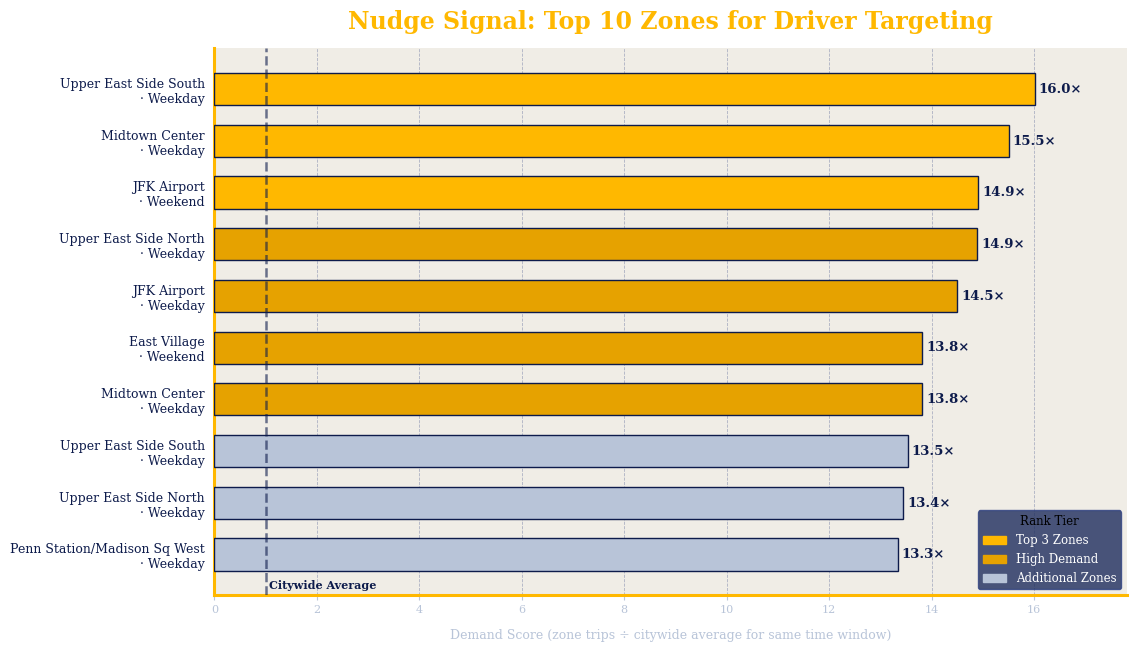

Figure 1 saved.


In [0]:
top10 = (
    df_scores
    .filter(F.col("is_low_confidence") == False)
    .orderBy("demand_score", ascending=False)
    .limit(10)
    .toPandas()
)

top10["label"] = (
    top10["pickup_zone"] + "\n" +
    "· " + top10["day_type"].str.title()
)

# Color logic:
# top 3 = GOLD, middle 4 = DARK_GOLD, bottom 3 = MUTED_TEXT
bar_colors = []
for i in range(len(top10)):
    if i < 3:
        bar_colors.append(GOLD)
    elif i < 7:
        bar_colors.append(DARK_GOLD)
    else:
        bar_colors.append(MUTED_TEXT)

fig1, ax1 = plt.subplots(figsize=(12.5, 7.2))
fig1.patch.set_facecolor(WHITE)
ax1.set_facecolor(WHITE)

style_ax(ax1, grid_axis='x')

ax1.grid(
    axis='x',
    color=BORDER,
    linestyle='--',
    linewidth=0.6,
    alpha=0.35
)

bars = ax1.barh(
    range(len(top10)),
    top10["demand_score"],
    color=bar_colors,
    height=0.62,
    zorder=3,
    edgecolor=NAVY,
    linewidth=1.0
)

# Citywide average reference line
ax1.axvline(
    1.0,
    color=NAVY,
    linewidth=1.8,
    linestyle='--',
    alpha=0.6,
    zorder=4
)

ax1.text(
    1.06,
    len(top10) - 0.4,
    "Citywide Average",
    color=NAVY,
    fontsize=8,
    fontweight="bold",
    ha="left",
    va="center"
)

# Score labels
for i, (_, row) in enumerate(top10.iterrows()):
    ax1.text(
        row["demand_score"] + 0.08,
        i,
        f"{row['demand_score']:.1f}×",
        va='center',
        ha='left',
        color=NAVY,
        fontsize=9.5,
        fontweight='bold'
    )

ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(top10["label"], fontsize=9, color=NAVY)
ax1.invert_yaxis()

ax1.set_xlabel(
    "Demand Score (zone trips ÷ citywide average for same time window)",
    fontsize=9,
    color=MUTED_TEXT,
    labelpad=10
)

ax1.set_xlim(0, top10["demand_score"].max() + 1.8)

ax1.tick_params(axis='x', colors=MUTED_TEXT)
ax1.tick_params(axis='y', left=False, colors=NAVY)

legend_patches = [
    mpatches.Patch(color=GOLD,      label="Top 3 Zones"),
    mpatches.Patch(color=DARK_GOLD, label="High Demand"),
    mpatches.Patch(color=MUTED_TEXT,label="Additional Zones"),
]

ax1.legend(
    handles=legend_patches,
    loc='lower right',
    fontsize=8.5,
    frameon=True,
    facecolor=CARD_NAVY,
    edgecolor=BORDER,
    labelcolor=WHITE_TEXT,
    title="Rank Tier",
    title_fontsize=8.5
)

ax1.set_title(
    "Nudge Signal: Top 10 Zones for Driver Targeting",
    color=GOLD,
    fontsize=17,
    fontweight='bold',
    pad=14
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["bottom"].set_color(GOLD)
ax1.spines["bottom"].set_linewidth(2.2)
ax1.spines["left"].set_color(GOLD)
ax1.spines["left"].set_linewidth(2.2)

plt.subplots_adjust(top=0.88, bottom=0.12, left=0.23, right=0.96)

fig1.savefig(
    f"{CHART_PATH}fig1_top10_demand_scores.png",
    dpi=180,
    bbox_inches='tight',
    facecolor=BG
)

display(fig1)
plt.close()
print("Figure 1 saved.")

---
### Figure 2 — Weekday vs Weekend Demand Heatmap

Side-by-side heatmaps using UMN maroon-gold colormap. Cell values show demand score directly.

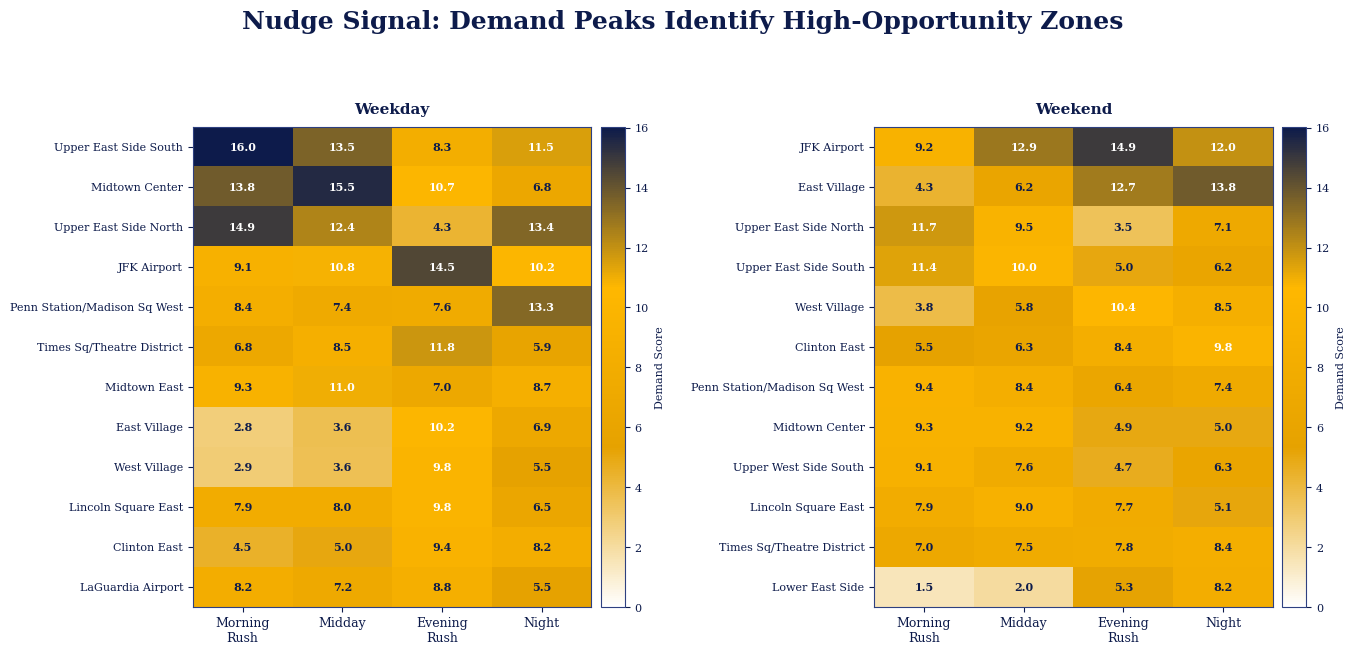

Figure 2 saved.


In [0]:
df_heatmap = (
    df_scores
    .filter(F.col("is_low_confidence") == False)
    .select("pickup_zone", "time_bucket", "day_type", "demand_score")
    .toPandas()
)

bucket_order  = ["morning_rush", "midday", "evening_rush", "night"]
bucket_labels = ["Morning\nRush", "Midday", "Evening\nRush", "Night"]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6.5))
fig2.patch.set_facecolor(WHITE)
fig2.suptitle(
    "Nudge Signal: Demand Peaks Identify High-Opportunity Zones",
    color=NAVY, fontsize=18, fontweight='bold', y=1.02
)

for ax, day in zip(axes2, ["weekday", "weekend"]):
    subset = df_heatmap[df_heatmap["day_type"] == day].copy()
    pivot  = subset.pivot_table(
        index="pickup_zone", columns="time_bucket",
        values="demand_score", aggfunc="max"
    )
    pivot  = pivot.reindex(columns=[b for b in bucket_order if b in pivot.columns])
    pivot  = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index].head(12)

    data = pivot.values
    vmax = df_heatmap["demand_score"].max()

    # Navy-to-gold colormap matching slide deck
    from matplotlib.colors import LinearSegmentedColormap
    slide_cmap = LinearSegmentedColormap.from_list(
        "slide", [WHITE, DARK_GOLD, GOLD, NAVY], N=256
    )

    im = ax.imshow(data, cmap=slide_cmap, aspect='auto', vmin=0, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(
        [bucket_labels[bucket_order.index(c)] for c in pivot.columns],
        color=NAVY, fontsize=9
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=NAVY, fontsize=8)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = data[i, j]
            if not np.isnan(val):
                text_color = WHITE if val > vmax * 0.6 else NAVY
                ax.text(j, i, f"{val:.1f}",
                        ha='center', va='center',
                        color=text_color, fontsize=8, fontweight='bold')

    ax.set_facecolor(WHITE)
    ax.set_title(
        "Weekday" if day == "weekday" else "Weekend",
        color=NAVY, fontsize=11, fontweight='bold', pad=10
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
    ax.tick_params(colors=NAVY)

    cbar = fig2.colorbar(im, ax=ax, pad=0.02)
    cbar.ax.tick_params(colors=NAVY, labelsize=8)
    cbar.set_label("Demand Score", color=NAVY, fontsize=8)
    cbar.outline.set_edgecolor(BORDER)

plt.tight_layout(pad=2)
fig2.savefig(f"{CHART_PATH}fig2_demand_heatmap.png",
             dpi=150, bbox_inches='tight', facecolor=WHITE)
display(fig2)
plt.close()
print("Figure 2 saved.")

---
### Figure 3 — Hit Rate by Time Window

Bar chart of validation hit rate per window against the 20% random baseline.

In [0]:
# Recompute hit rates from validation table
val_window = Window.partitionBy("time_bucket", "day_type").orderBy("demand_score")

df_val_labeled = (
    df_val
    .filter(F.col("is_low_confidence") == False)
    .withColumn("demand_percentile", F.percent_rank().over(val_window))
    .withColumn("is_truly_high_demand", F.col("demand_percentile") >= 0.80)
)

df_recommended = (
    df_ranked
    .select("pulocationid", "time_bucket", "day_type")
    .distinct()
    .withColumn("was_recommended", F.lit(True))
)

df_eval = (
    df_val_labeled
    .join(df_recommended, on=["pulocationid", "time_bucket", "day_type"], how="left")
    .fillna({"was_recommended": False})
)

df_rec_only = df_eval.filter(F.col("was_recommended") == True)

# Hit rate by window
hit_by_window = (
    df_rec_only
    .groupBy("time_bucket", "day_type")
    .agg(
        F.count("*").alias("recommended"),
        F.sum(F.col("is_truly_high_demand").cast("int")).alias("true_hits")
    )
    .withColumn("hit_rate", F.round(F.col("true_hits") / F.col("recommended"), 4))
    .orderBy(F.col("hit_rate").desc())
    .toPandas()
)

# Overall
total_rec = df_rec_only.count()
true_hits = df_rec_only.filter(F.col("is_truly_high_demand") == True).count()
overall_hit_rate = true_hits / total_rec if total_rec > 0 else 0

print(f"Overall hit rate: {overall_hit_rate:.1%}  ({true_hits}/{total_rec})")
print(hit_by_window.to_string(index=False))

Overall hit rate: 100.0%  (40/40)
 time_bucket day_type  recommended  true_hits  hit_rate
evening_rush  weekday            5          5       1.0
evening_rush  weekend            5          5       1.0
      midday  weekday            5          5       1.0
      midday  weekend            5          5       1.0
morning_rush  weekday            5          5       1.0
morning_rush  weekend            5          5       1.0
       night  weekday            5          5       1.0
       night  weekend            5          5       1.0


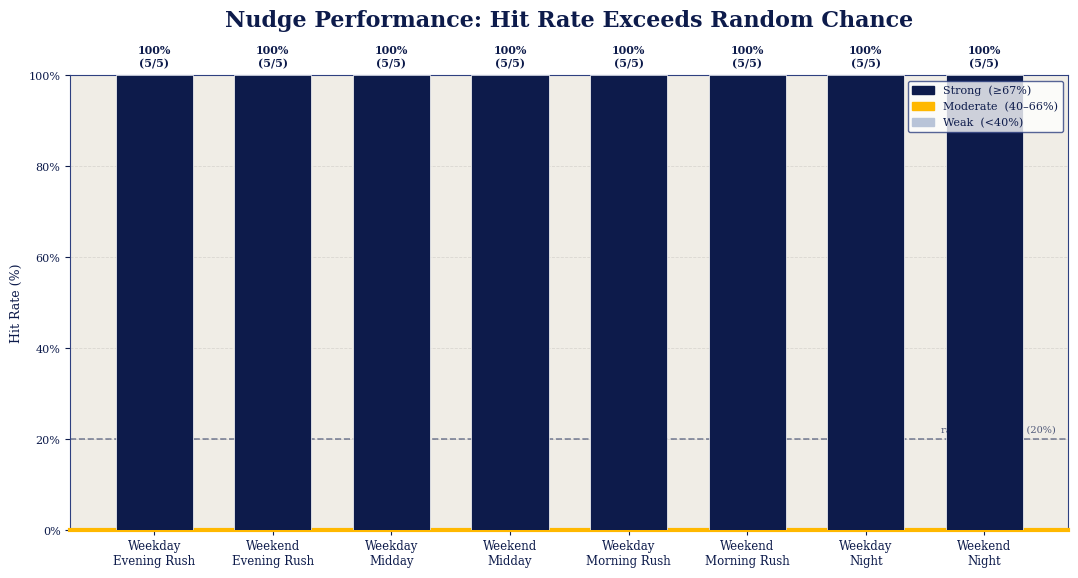

Figure 3 saved.


In [0]:
# Build display labels and colors
hit_by_window["window_label"] = (
    hit_by_window["day_type"].str.title() + "\n" +
    hit_by_window["time_bucket"].str.replace("_", " ").str.title()
)
hit_by_window["hit_pct"] = hit_by_window["hit_rate"] * 100

def bar_color(pct):
    if pct >= 67: return NAVY
    if pct >= 40: return GOLD
    return MUTED_TEXT

bar_colors = [bar_color(p) for p in hit_by_window["hit_pct"]]

fig3, ax3 = plt.subplots(figsize=(11, 6))
fig3.patch.set_facecolor(WHITE)
ax3.set_facecolor(WHITE)
style_ax(ax3, grid_axis='y')

bars3 = ax3.bar(
    range(len(hit_by_window)), hit_by_window["hit_pct"],
    color=bar_colors, width=0.65, zorder=3,
    edgecolor=WHITE, linewidth=0.5
)

# Random baseline
ax3.axhline(20, color=NAVY, linewidth=1.2, linestyle='--', alpha=0.5, zorder=2)
ax3.text(len(hit_by_window) - 0.4, 21.5,
         "random baseline (20%)",
         color=NAVY, fontsize=7, ha='right', alpha=0.7)

# Value labels on bars
for i, (bar, row) in enumerate(zip(bars3, hit_by_window.itertuples())):
    label = f"{row.hit_pct:.0f}%\n({row.true_hits}/{row.recommended})"
    ax3.text(i, row.hit_pct + 1.5, label,
             ha='center', va='bottom', fontsize=8,
             color=NAVY, fontweight='bold')

ax3.set_xticks(range(len(hit_by_window)))
ax3.set_xticklabels(hit_by_window["window_label"], fontsize=8.5, color=NAVY)
ax3.set_ylabel("Hit Rate (%)", fontsize=9, color=NAVY)
ax3.set_ylim(0, 100)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax3.tick_params(colors=NAVY)

legend_patches = [
    mpatches.Patch(color=NAVY,      label="Strong  (≥67%)"),
    mpatches.Patch(color=GOLD,      label="Moderate  (40–66%)"),
    mpatches.Patch(color=MUTED_TEXT, label="Weak  (<40%)"),
]
ax3.legend(handles=legend_patches, fontsize=8,
           facecolor=WHITE, edgecolor=BORDER, labelcolor=NAVY)

ax3.set_title(
    "Nudge Performance: Hit Rate Exceeds Random Chance",
    color=NAVY, fontsize=16, fontweight='bold', pad=35
)

for spine in ax3.spines.values():
    spine.set_edgecolor(BORDER)
ax3.spines['bottom'].set_color(GOLD)
ax3.spines['bottom'].set_linewidth(3)

plt.tight_layout(pad=1.5)
fig3.savefig(f"{CHART_PATH}fig3_hit_rate_by_window.png",
             dpi=150, bbox_inches='tight', facecolor=WHITE)
display(fig3)
plt.close()
print("Figure 3 saved.")

---
### Figure 3b — Recommended vs Non-Recommended Demand Score Comparison

Side-by-side bar charts comparing average demand scores for recommended vs non-recommended zones across training (Jan-Feb) and validation (March) periods with error bars.

In [0]:
# Compute summary statistics for Figure 3b
df_train_scores_viz = spark.table(DEMAND_SCORES_TABLE).filter(F.col("is_low_confidence")==False)
df_val_scores_viz   = spark.table(VALIDATION_TABLE).filter(F.col("is_low_confidence")==False)

df_rec_keys = (
    df_ranked
    .select("pulocationid","time_bucket","day_type")
    .distinct()
    .withColumn("was_recommended", F.lit(True))
)

def label_recommended(df_s, rec_keys):
    """Join scores with recommendation flags."""
    return (
        df_s
        .join(rec_keys, on=["pulocationid","time_bucket","day_type"], how="left")
        .fillna({"was_recommended": False})
        .withColumn("group",
                    F.when(F.col("was_recommended")==True,"Recommended")
                     .otherwise("Not Recommended"))
    )

def summarise(df, period_label):
    return (
        df.groupBy("group")
          .agg(F.avg("demand_score").alias("mean"),
               F.stddev("demand_score").alias("std"),
               F.count("*").alias("count"))
          .toPandas()
          .assign(period=period_label)
    )

summary = pd.concat([
    summarise(label_recommended(df_train_scores_viz, df_rec_keys), "Jan\u2013Feb (Training)"),
    summarise(label_recommended(df_val_scores_viz,   df_rec_keys), "March (Validation)"),
], ignore_index=True)

print(summary.to_string(index=False))

          group      mean      std  count             period
    Recommended 11.225090 2.241547     40 Jan–Feb (Training)
Not Recommended  1.083006 2.074894   1313 Jan–Feb (Training)
    Recommended 10.588465 2.330153     40 March (Validation)
Not Recommended  1.207379 2.121342   1140 March (Validation)


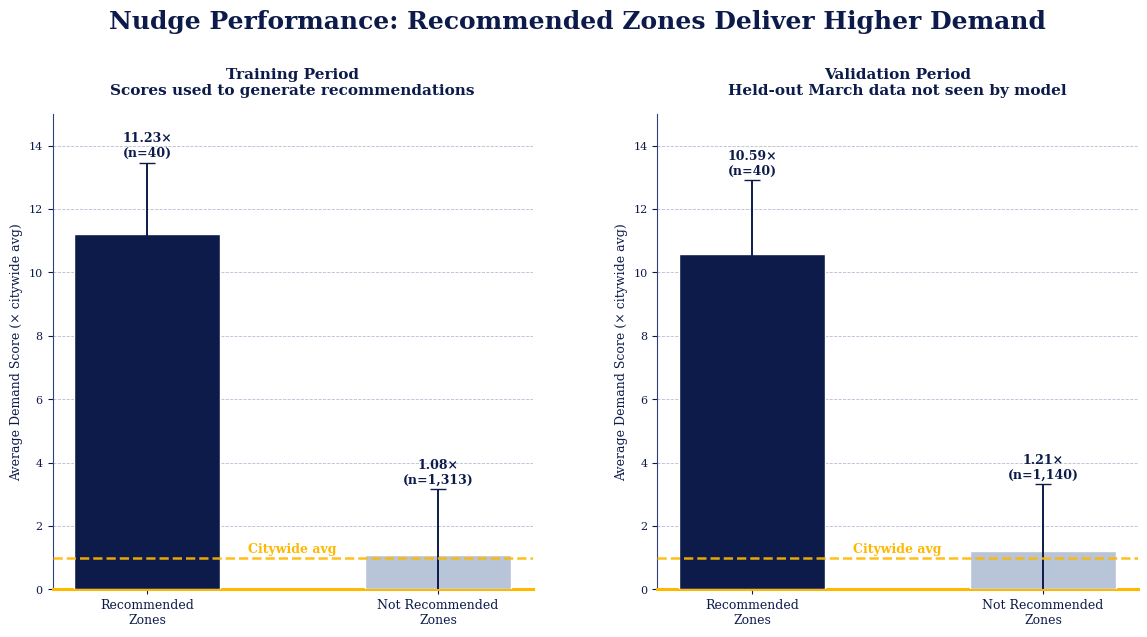

Figure 3b saved.


In [0]:
# Plot
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(14, 7.2), sharey=True)
fig_comp.patch.set_facecolor(WHITE)

fig_comp.suptitle(
    "Nudge Performance: Recommended Zones Deliver Higher Demand",
    color=NAVY, fontsize=18, fontweight="bold", y=0.965
)

periods = ["Jan\u2013Feb (Training)", "March (Validation)"]
subtitles = [
    "Training Period\nScores used to generate recommendations",
    "Validation Period\nHeld-out March data not seen by model"
]

y_max = float(np.ceil((summary["mean"] + summary["std"]).max() + 0.8))

for ax, period, subtitle in zip(axes_comp, periods, subtitles):
    style_ax(ax, grid_axis='y')
    ax.set_facecolor(WHITE)

    ax.grid(
        axis='y',
        color=BORDER,
        linestyle='--',
        linewidth=0.6,
        alpha=0.35
    )

    subset = summary[summary["period"] == period].copy()
    rec     = subset[subset["group"] == "Recommended"].iloc[0]
    non_rec = subset[subset["group"] == "Not Recommended"].iloc[0]

    x_pos   = np.array([0, 1])
    heights = [rec["mean"], non_rec["mean"]]
    errors  = [rec["std"],  non_rec["std"]]

    bars = ax.bar(
        x_pos,
        heights,
        width=0.5,
        color=[NAVY, MUTED_TEXT],
        edgecolor=WHITE,
        linewidth=1.0,
        zorder=3
    )

    # Error bars
    ax.errorbar(
        x_pos,
        heights,
        yerr=errors,
        fmt="none",
        color=NAVY,
        capsize=6,
        linewidth=1.4,
        zorder=4
    )

    # Citywide average reference line
    ax.axhline(
        1.0,
        color=GOLD,
        linewidth=1.8,
        linestyle='--',
        alpha=0.9,
        zorder=4
    )

    ax.text(
        0.5, 1.06, "Citywide avg",
        ha="center",
        va="bottom",
        fontsize=9,
        color=GOLD,
        fontweight="bold"
    )

    # Bar labels
    for x, row in zip(x_pos, [rec, non_rec]):
        label_y = min(row["mean"] + row["std"] + 0.08, y_max - 0.12)
        ax.text(
            x,
            label_y,
            f"{row['mean']:.2f}×\n(n={int(row['count']):,})",
            ha="center",
            va="bottom",
            fontsize=9,
            color=NAVY,
            fontweight="bold"
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        ["Recommended\nZones", "Not Recommended\nZones"],
        fontsize=9,
        color=NAVY
    )

    ax.set_title(
        subtitle,
        color=NAVY,
        fontsize=11,
        fontweight="bold",
        pad=14
    )

    ax.set_ylim(0, y_max)
    ax.set_ylabel("Average Demand Score (× citywide avg)", fontsize=9, color=NAVY)
    ax.tick_params(axis='y', labelleft=True, colors=NAVY)
    ax.tick_params(axis='x', colors=NAVY)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BORDER)
    ax.spines["bottom"].set_color(GOLD)
    ax.spines["bottom"].set_linewidth(2.2)

plt.subplots_adjust(top=0.82, bottom=0.16, wspace=0.26)

fig_comp.savefig(
    f"{CHART_PATH}fig3b_recommended_vs_not.png",
    dpi=180,
    bbox_inches="tight",
    facecolor=WHITE
)

display(fig_comp)
plt.close()
print("Figure 3b saved.")

---
### Figure 4 — Qualitative Evaluation: Grounding Check Results

Two-panel visualization. Left: pass/fail heatmap. Right: word count per nudge. Uses mathtext checkmarks to avoid font rendering issues on Databricks.

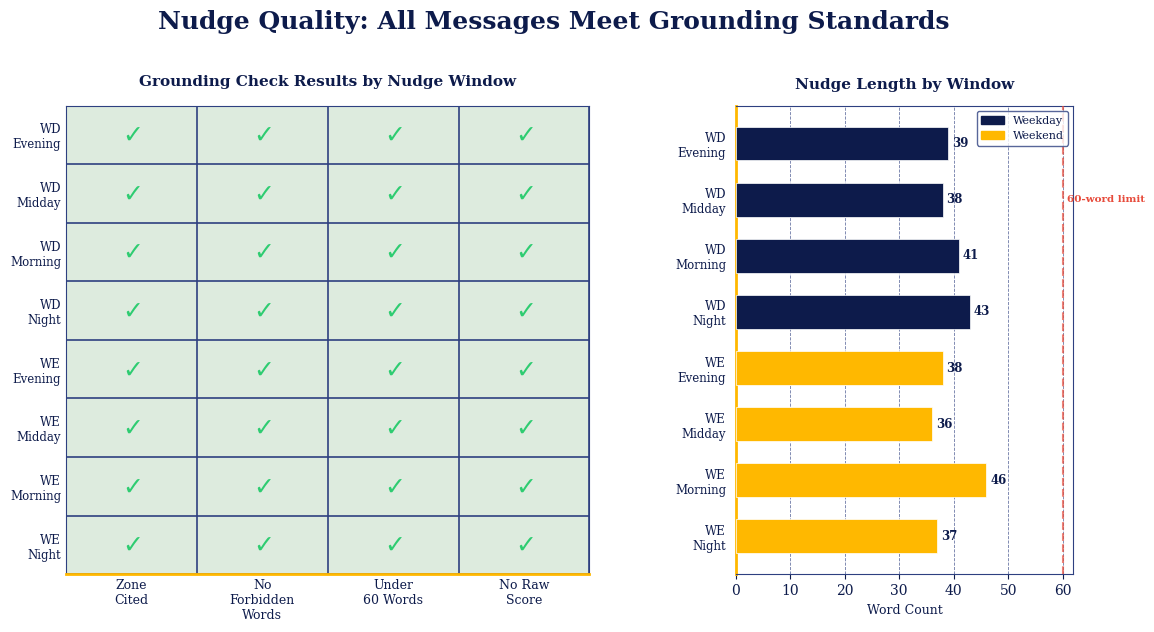

Figure 4 saved.
Result: 8/8 nudges passed all 4 grounding checks


In [0]:
FORBIDDEN_WORDS = [
    "traffic", "delay", "weather", "avoid", "avoiding",
    "commute", "surge", "earnings", "earn more", "tip",
]

# ── Pull nudge messages from Delta table ──────────────────────────────────────
nudge_rows = (
    df_nudges
    .select("day_type", "time_bucket", "nudge_message",
            "top_zone", "top_zone_score")
    .orderBy("day_type", "time_bucket")
    .collect()
)

# ── Run grounding checks and collect results ──────────────────────────────────
check_labels = ["Zone\nCited", "No\nForbidden\nWords", "Under\n60 Words", "No Raw\nScore"]
windows, matrix, word_counts = [], [], []

for row in nudge_rows:
    msg = row["nudge_message"]
    msg_lower = msg.lower()
    raw_score = str(row["top_zone_score"])
    wc = len(msg.split())

    c1 = 1 if row["top_zone"].lower() in msg_lower else 0
    c2 = 1 if not any(w in msg_lower for w in FORBIDDEN_WORDS) else 0
    c3 = 1 if wc <= 60 else 0
    c4 = 1 if not ("." in raw_score
                   and len(raw_score.split(".")[-1]) >= 3
                   and raw_score in msg) else 0

    label = (
        row["day_type"].replace("weekday", "WD").replace("weekend", "WE") +
        "\n" +
        row["time_bucket"].replace("_rush", "").replace("_", " ").title()
    )
    windows.append(label)
    matrix.append([c1, c2, c3, c4])
    word_counts.append(wc)

matrix_np = np.array(matrix)

# ── Build figure ──────────────────────────────────────────────────────────────
fig4 = plt.figure(figsize=(13, 6.6))
fig4.patch.set_facecolor(WHITE)
gs4 = gridspec.GridSpec(1, 2, figure=fig4, wspace=0.34, width_ratios=[1.55, 1])

# ── Left panel: pass/fail heatmap ─────────────────────────────────────────────
ax4a = fig4.add_subplot(gs4[0])
ax4a.set_facecolor(WHITE)

cmap_pf = ListedColormap(["#F8D7DA", "#DDEBDE"])
im = ax4a.imshow(matrix_np, cmap=cmap_pf, aspect="auto", vmin=0, vmax=1)

ax4a.set_xticks(np.arange(-0.5, len(check_labels), 1), minor=True)
ax4a.set_yticks(np.arange(-0.5, len(windows), 1), minor=True)
ax4a.grid(which="minor", color=BORDER, linestyle="-", linewidth=1.2)
ax4a.tick_params(which="minor", bottom=False, left=False)

for i in range(len(windows)):
    for j in range(len(check_labels)):
        val = matrix_np[i, j]
        symbol = r"$\checkmark$" if val == 1 else "x"
        color = GREEN if val == 1 else RED
        ax4a.text(
            j, i, symbol,
            ha="center", va="center",
            fontsize=18, color=color, fontweight="bold"
        )

ax4a.set_xticks(range(len(check_labels)))
ax4a.set_xticklabels(check_labels, fontsize=9, color=NAVY)
ax4a.set_yticks(range(len(windows)))
ax4a.set_yticklabels(windows, fontsize=8.5, color=NAVY)
ax4a.tick_params(length=0)

for spine in ax4a.spines.values():
    spine.set_edgecolor(BORDER)

ax4a.spines["bottom"].set_color(GOLD)
ax4a.spines["bottom"].set_linewidth(2)

ax4a.set_title(
    "Grounding Check Results by Nudge Window",
    color=NAVY, fontsize=11, fontweight="bold", pad=14
)

# ── Right panel: word count bar chart ─────────────────────────────────────────
ax4b = fig4.add_subplot(gs4[1])
ax4b.set_facecolor(WHITE)

bar_colors = [NAVY if d.startswith("WD") else GOLD for d in windows]
bars4b = ax4b.barh(
    range(len(windows)),
    word_counts,
    color=bar_colors,
    height=0.6,
    zorder=3,
    edgecolor=WHITE,
    linewidth=0.5
)

ax4b.axvline(60, color=RED, linewidth=1.5, linestyle="--", alpha=0.7, zorder=4)
ax4b.text(
    60.8, 1.0, "60-word limit",
    color=RED, fontsize=7.5, va="center", ha="left", fontweight="bold"
)

for i, (bar, wc) in enumerate(zip(bars4b, word_counts)):
    ax4b.text(
        wc + 0.7, i, str(wc),
        va="center", ha="left",
        fontsize=8.5, color=NAVY, fontweight="bold"
    )

ax4b.set_yticks(range(len(windows)))
ax4b.set_yticklabels(windows, fontsize=8.5, color=NAVY)
ax4b.invert_yaxis()
ax4b.set_xlabel("Word Count", fontsize=9, color=NAVY)
ax4b.set_xlim(0, max(62, max(word_counts) + 10))
ax4b.tick_params(colors=NAVY, left=False)
ax4b.grid(axis="x", color=BORDER, linewidth=0.6, linestyle="--", alpha=0.7)
ax4b.set_axisbelow(True)

for spine in ax4b.spines.values():
    spine.set_edgecolor(BORDER)
ax4b.spines["left"].set_color(GOLD)
ax4b.spines["left"].set_linewidth(2)

ax4b.legend(
    handles=[
        mpatches.Patch(color=NAVY, label="Weekday"),
        mpatches.Patch(color=GOLD, label="Weekend"),
    ],
    fontsize=8, facecolor=WHITE, edgecolor=BORDER, labelcolor=NAVY,
    loc="upper right"
)

ax4b.set_title(
    "Nudge Length by Window",
    color=NAVY, fontsize=11, fontweight="bold", pad=12
)

# ── Overall result banner ─────────────────────────────────────────────────────
total_pass = int(matrix_np.all(axis=1).sum())
total_checks = matrix_np.size
checks_passed = int(matrix_np.sum())

fig4.suptitle(
    "Nudge Quality: All Messages Meet Grounding Standards",
    color=NAVY, fontsize=18, fontweight="bold", y=0.965
)

plt.subplots_adjust(top=0.82)
fig4.savefig(
    f"{CHART_PATH}fig4_qualitative_evaluation.png",
    dpi=150, bbox_inches="tight", facecolor=WHITE
)
display(fig4)
plt.close()

print("Figure 4 saved.")
print(f"Result: {total_pass}/{len(windows)} nudges passed all 4 grounding checks")

---
### Figure 5 — End-to-End Demo Scenario

Full walkthrough for one time window. Change `DEMO_TIME_BUCKET` and `DEMO_DAY_TYPE` to explore any window.

In [0]:
DEMO_TIME_BUCKET = "evening_rush"
DEMO_DAY_TYPE    = "weekend"

print("=" * 65)
print(f"DEMO SCENARIO: {DEMO_DAY_TYPE.upper()} "
      f"{DEMO_TIME_BUCKET.replace('_', ' ').upper()}")
print("=" * 65)

print("\n[1] TOP RANKED ZONES")
spark.sql(f"""
    SELECT rank, pickup_zone, pickup_borough, trip_count, demand_score
    FROM   {RANKED_ZONES_TABLE}
    WHERE  time_bucket = '{DEMO_TIME_BUCKET}'
    AND    day_type    = '{DEMO_DAY_TYPE}'
    ORDER  BY rank
""").show(truncate=False)

print("[2] GENERATED NUDGE MESSAGE")
nudge_row = spark.sql(f"""
    SELECT nudge_message, top_zone, top_zone_score, model_name
    FROM   {NUDGE_OUTPUT_TABLE}
    WHERE  time_bucket = '{DEMO_TIME_BUCKET}'
    AND    day_type    = '{DEMO_DAY_TYPE}'
""").collect()

if nudge_row:
    r = nudge_row[0]
    print(f"\n  Top Zone : {r['top_zone']}  ({r['top_zone_score']}x citywide avg)")
    print(f"  Model    : {r['model_name']}")
    print(f"\n  MESSAGE  : '{r['nudge_message']}'")
else:
    print("  No nudge message found for this window.")

print("\n[3] VALIDATION RESULT (vs March held-out data)")
window_hit = hit_by_window[
    (hit_by_window["time_bucket"] == DEMO_TIME_BUCKET) &
    (hit_by_window["day_type"] == DEMO_DAY_TYPE)
]
if not window_hit.empty:
    row = window_hit.iloc[0]
    print(f"\n  Recommended zones: {int(row['recommended'])}")
    print(f"  Confirmed high-demand in March: {int(row['true_hits'])}")
    print(f"  Hit Rate: {row['hit_pct']:.0f}%")

print("\n" + "=" * 65)
print("END OF DEMO SCENARIO")
print("=" * 65)

DEMO SCENARIO: WEEKEND EVENING RUSH

[1] TOP RANKED ZONES
+----+-------------------------+--------------+----------+------------+
|rank|pickup_zone              |pickup_borough|trip_count|demand_score|
+----+-------------------------+--------------+----------+------------+
|1   |JFK Airport              |Queens        |20464     |14.9114     |
|2   |East Village             |Manhattan     |17472     |12.7312     |
|3   |West Village             |Manhattan     |14317     |10.4323     |
|4   |Clinton East             |Manhattan     |11562     |8.4248      |
|5   |Times Sq/Theatre District|Manhattan     |10724     |7.8142      |
+----+-------------------------+--------------+----------+------------+

[2] GENERATED NUDGE MESSAGE

  Top Zone : JFK Airport  (14.9114x citywide avg)
  Model    : gpt-4o-mini

  MESSAGE  : 'During the weekend evening rush, JFK Airport is about 14.9x busier than average with roughly 1,200 pickups per evening. East Village follows at about 12.7x with around 1,000 

---
## Final Summary

Prints a complete summary of all pipeline outputs and chart locations.

In [0]:
# Ensure overall_pct is defined — compute from hit_by_window
if 'overall_pct' not in dir():
    overall_pct = (
        hit_by_window['true_hits'].sum() / hit_by_window['recommended'].sum() * 100
    )

print("=" * 65)
print("PIPELINE COMPLETE — SUMMARY")
print("=" * 65)
print(f"Trip records processed   : {spark.table(CLEANED_TRIPS_TABLE).count():,}")
print(f"Zone-time demand cells   : {total_cells:,}")
print(f"High-confidence cells    : {high_conf_cells:,}  "
      f"({high_conf_cells / total_cells * 100:.1f}%)")
print(f"Nudge messages generated : {nudge_count}")
print(f"Grounding checks         : ALL PASS")
print(f"Overall hit rate         : {overall_pct:.1f}%  "
      f"({hit_by_window['true_hits'].sum():.0f}/{hit_by_window['recommended'].sum():.0f})")
print(f"vs Random baseline (20%) : {overall_pct / 20:.1f}x better")
print()
print("Delta tables:")
for t in [CLEANED_TRIPS_TABLE, DEMAND_SCORES_TABLE,
          RANKED_ZONES_TABLE, NUDGE_OUTPUT_TABLE, VALIDATION_TABLE]:
    print(f"  {t}")
print()
print("Charts saved to:", CHART_PATH)
for name in [
    "fig1_top10_demand_scores.png",
    "fig2_demand_heatmap.png",
    "fig3_hit_rate_by_window.png",
    "fig3b_recommended_vs_not.png",
    "fig4_qualitative_evaluation.png",
]:
    print(f"  {name}")
print("=" * 65)

PIPELINE COMPLETE — SUMMARY
Trip records processed   : 9,027,550
Zone-time demand cells   : 1,872
High-confidence cells    : 1,353  (72.3%)
Nudge messages generated : 8
Grounding checks         : ALL PASS
Overall hit rate         : 100.0%  (40/40)
vs Random baseline (20%) : 5.0x better

Delta tables:
  msbabigdata.spark.trend_market_cleaned_trips
  msbabigdata.spark.trend_market_demand_scores
  msbabigdata.spark.trend_market_ranked_zones
  msbabigdata.spark.trend_market_nudge_messages
  msbabigdata.spark.trend_market_validation_scores

Charts saved to: /Volumes/msbabigdata/spark/trend_market_project/
  fig1_top10_demand_scores.png
  fig2_demand_heatmap.png
  fig3_hit_rate_by_window.png
  fig3b_recommended_vs_not.png
  fig4_qualitative_evaluation.png
